# 11 Seaborn Visualizations

This notebook uses **CSV file** to demonstrate:

1. Bar Graph
2. Histogram
3. Line Graph
4. Time Series Line Chart
5. Scatter Plot
6. Count Plot
7. Bubble Chart
8. Pie Chart
9. Box Plot
10. Heatmap
11. Pairplot


The notebook primarily uses **Seaborn**. Matplotlib is used only for figure sizing, axis formatting, and the pie chart where needed.

In [1]:
# Run this cell if Seaborn/Pandas/Matplotlib are not installed:
# !pip install pandas numpy seaborn matplotlib jupyter

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



DATA_FILE = "/content/data_visualization_dataset.csv"

df = pd.read_csv(DATA_FILE, parse_dates=["Order_Date"])

print("Shape:", df.shape)
display(df.head())


Shape: (10000, 18)


,Order_ID,Order_Date,Region,Category,Subcategory,Customer_Segment,Payment_Method,Sales_Channel,Customer_Age,Quantity,Unit_Price,Discount_Pct,Sales,Profit,Rating,Delivery_Days,Marketing_Spend,Satisfaction_Score
0,1,2022-01-01,West,Grocery,Standard,Consumer,Credit Card,Distributor,42,5,1320.85,10.62,5902.88,665.44,4.1,5.7,156.41,3.9
1,2,2022-01-01,East,Grocery,Economy,Consumer,Credit Card,Online,24,6,990.60,8.49,5438.99,479.18,3.9,3.6,314.00,3.7
2,3,2022-01-01,Central,Electronics,Premium,Home Office,Credit Card,Retail Store,59,4,28085.73,10.77,100243.59,15525.78,3.4,3.3,3668.39,3.9
3,4,2022-01-01,West,Electronics,Premium,Consumer,Credit Card,Online,23,4,27777.42,6.76,103598.67,10903.19,4.2,6.8,7708.67,4.5
4,5,2022-01-01,North,Furniture,Standard,Consumer,Cash,Retail Store,44,8,14413.10,9.73,104085.64,22227.81,4.0,4.2,1085.81,4.1


## 1. Bar Graph

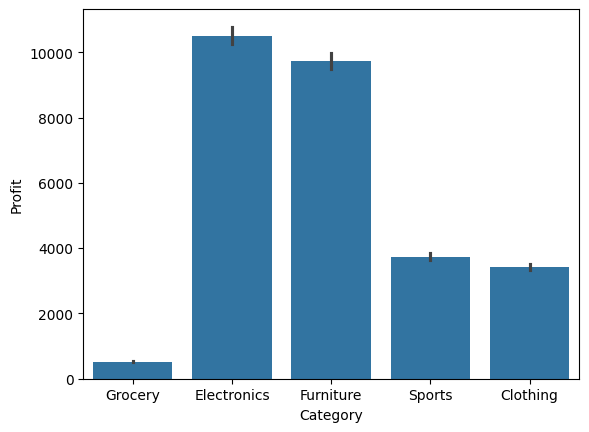

In [3]:
# Bar Graph
sns.barplot(data=df, x="Category", y="Profit")
plt.show()


## 2. Histogram

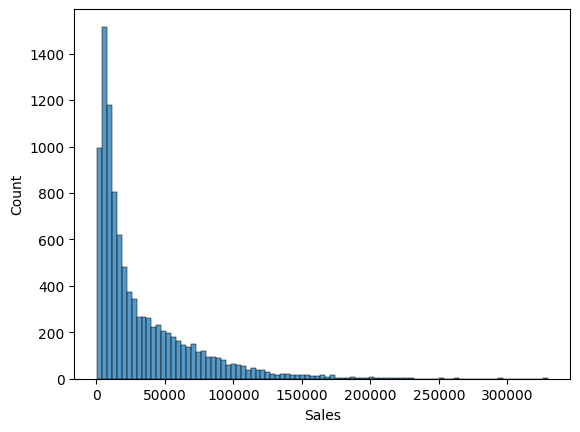

In [4]:
# Histogram
sns.histplot(df["Sales"])
plt.show()


## 3. Line Graph

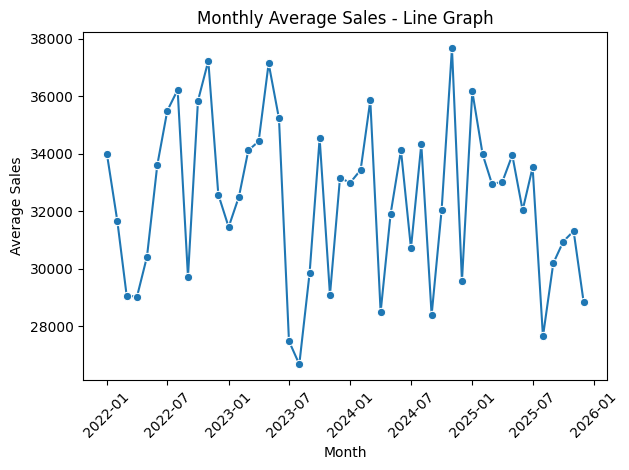

In [5]:
# Monthly average sales over the complete dataset
monthly_sales = (
    df.assign(Month=df["Order_Date"].dt.to_period("M").dt.to_timestamp())
    .groupby("Month", as_index=False)["Sales"]
    .mean()
)

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    marker="o"
)
plt.title("Monthly Average Sales - Line Graph")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Time Series Line Chart

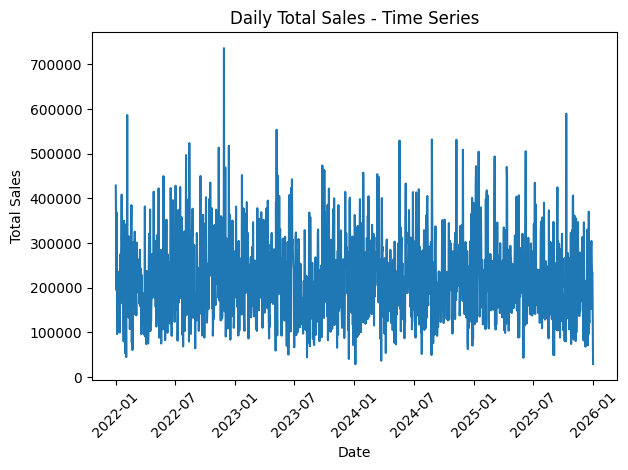

In [6]:
# Daily total sales, using the actual date column as the time axis
daily_sales = (
    df.groupby("Order_Date", as_index=False)["Sales"]
    .sum()
    .sort_values("Order_Date")
)

sns.lineplot(
    data=daily_sales,
    x="Order_Date",
    y="Sales"
)
plt.title("Daily Total Sales - Time Series")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Scatter Plot

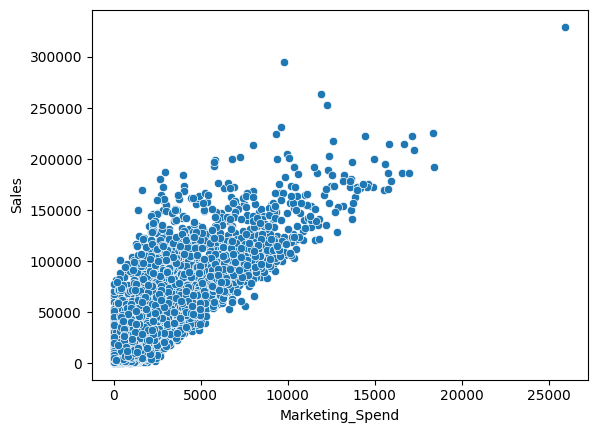

In [7]:
# Scatter Plot
sns.scatterplot(data=df, x="Marketing_Spend", y="Sales")
plt.show()


## 6. Count Plot

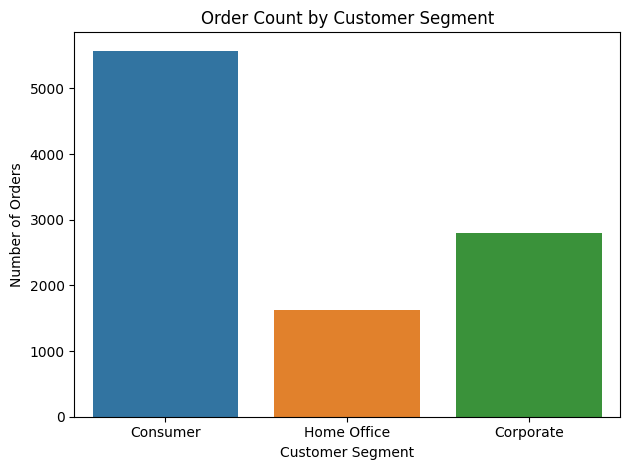

In [8]:
# Number of orders in each customer segment
sns.countplot(
    data=df,
    x="Customer_Segment",
    hue="Customer_Segment",
    legend=False
)
plt.title("Order Count by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## 7. Bubble Chart

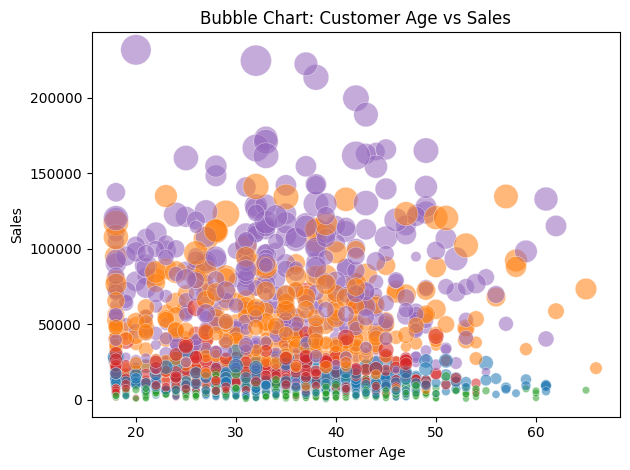

In [11]:
# Bubble chart:
# X = Customer Age, Y = Sales, Bubble Size = Profit, Color = Category
bubble_df = df.sample(1800, random_state=42).copy()

sns.scatterplot(
    data=bubble_df,
    x="Customer_Age",
    y="Sales",
    size="Profit",
    sizes=(20, 500),
    hue="Category",
    alpha=0.55,
    legend=False
)
plt.title("Bubble Chart: Customer Age vs Sales")
plt.xlabel("Customer Age")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

## 8. Pie Chart

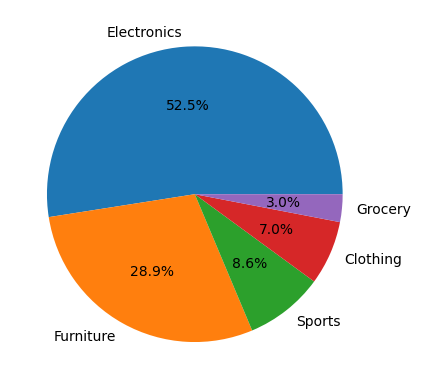

In [14]:
# Pie Chart
pie_data = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.pie(pie_data, labels=pie_data.index,autopct="%1.1f%%")
plt.show()


## 9. Box Plot

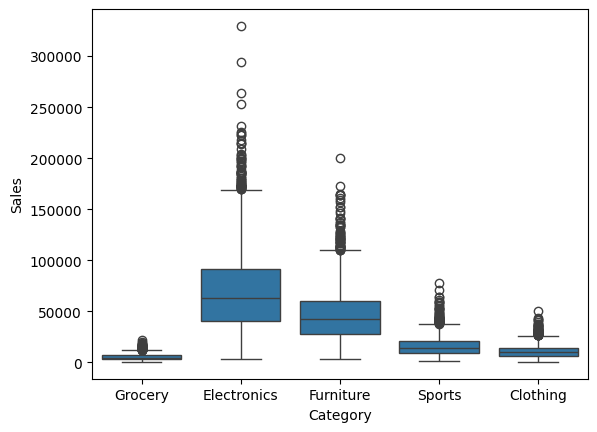

In [13]:
# Box Plot
sns.boxplot(data=df, x="Category", y="Sales")
plt.show()

## 10. Heatmap

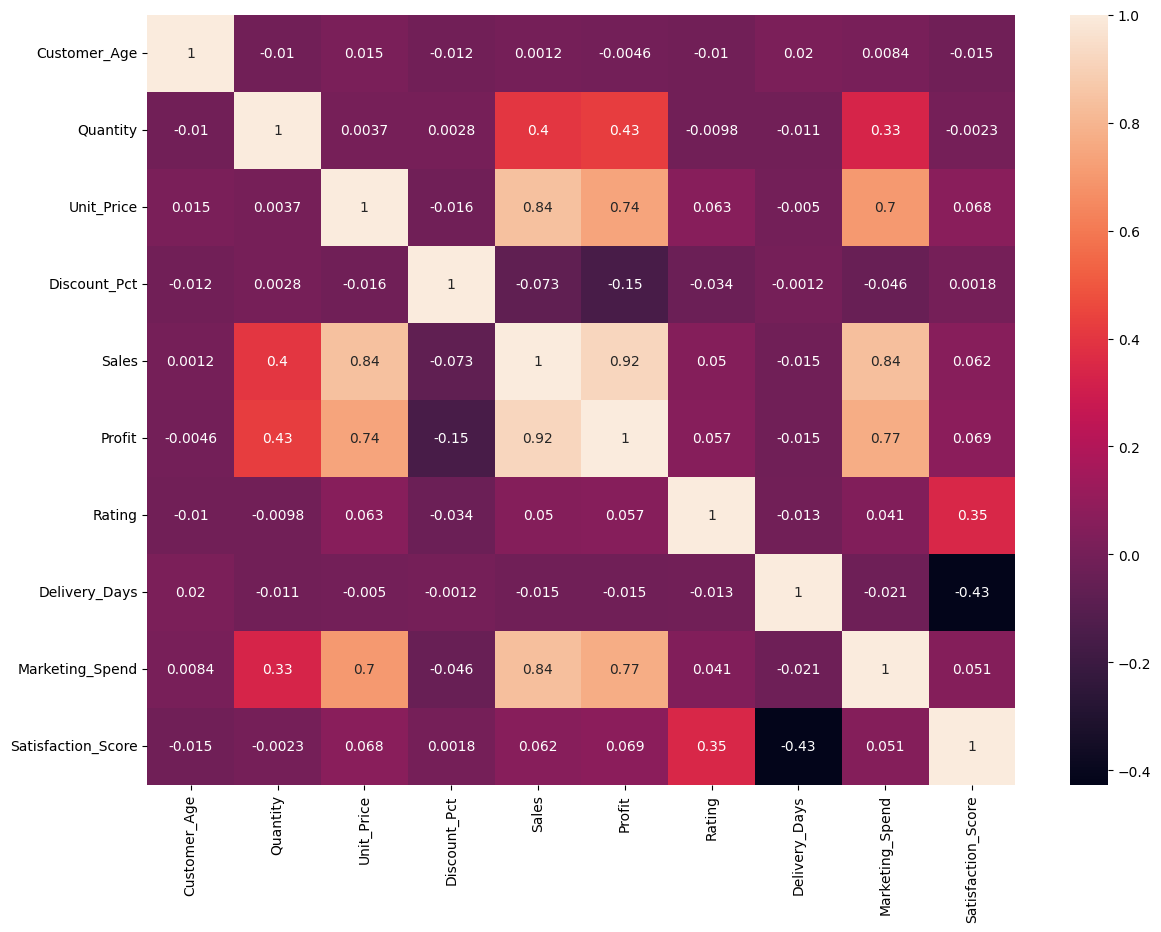

In [15]:
# Heatmap
numeric_cols = [
    "Customer_Age",
    "Quantity",
    "Unit_Price",
    "Discount_Pct",
    "Sales",
    "Profit",
    "Rating",
    "Delivery_Days",
    "Marketing_Spend",
    "Satisfaction_Score",
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True)
plt.show()


## 11. Pairplot

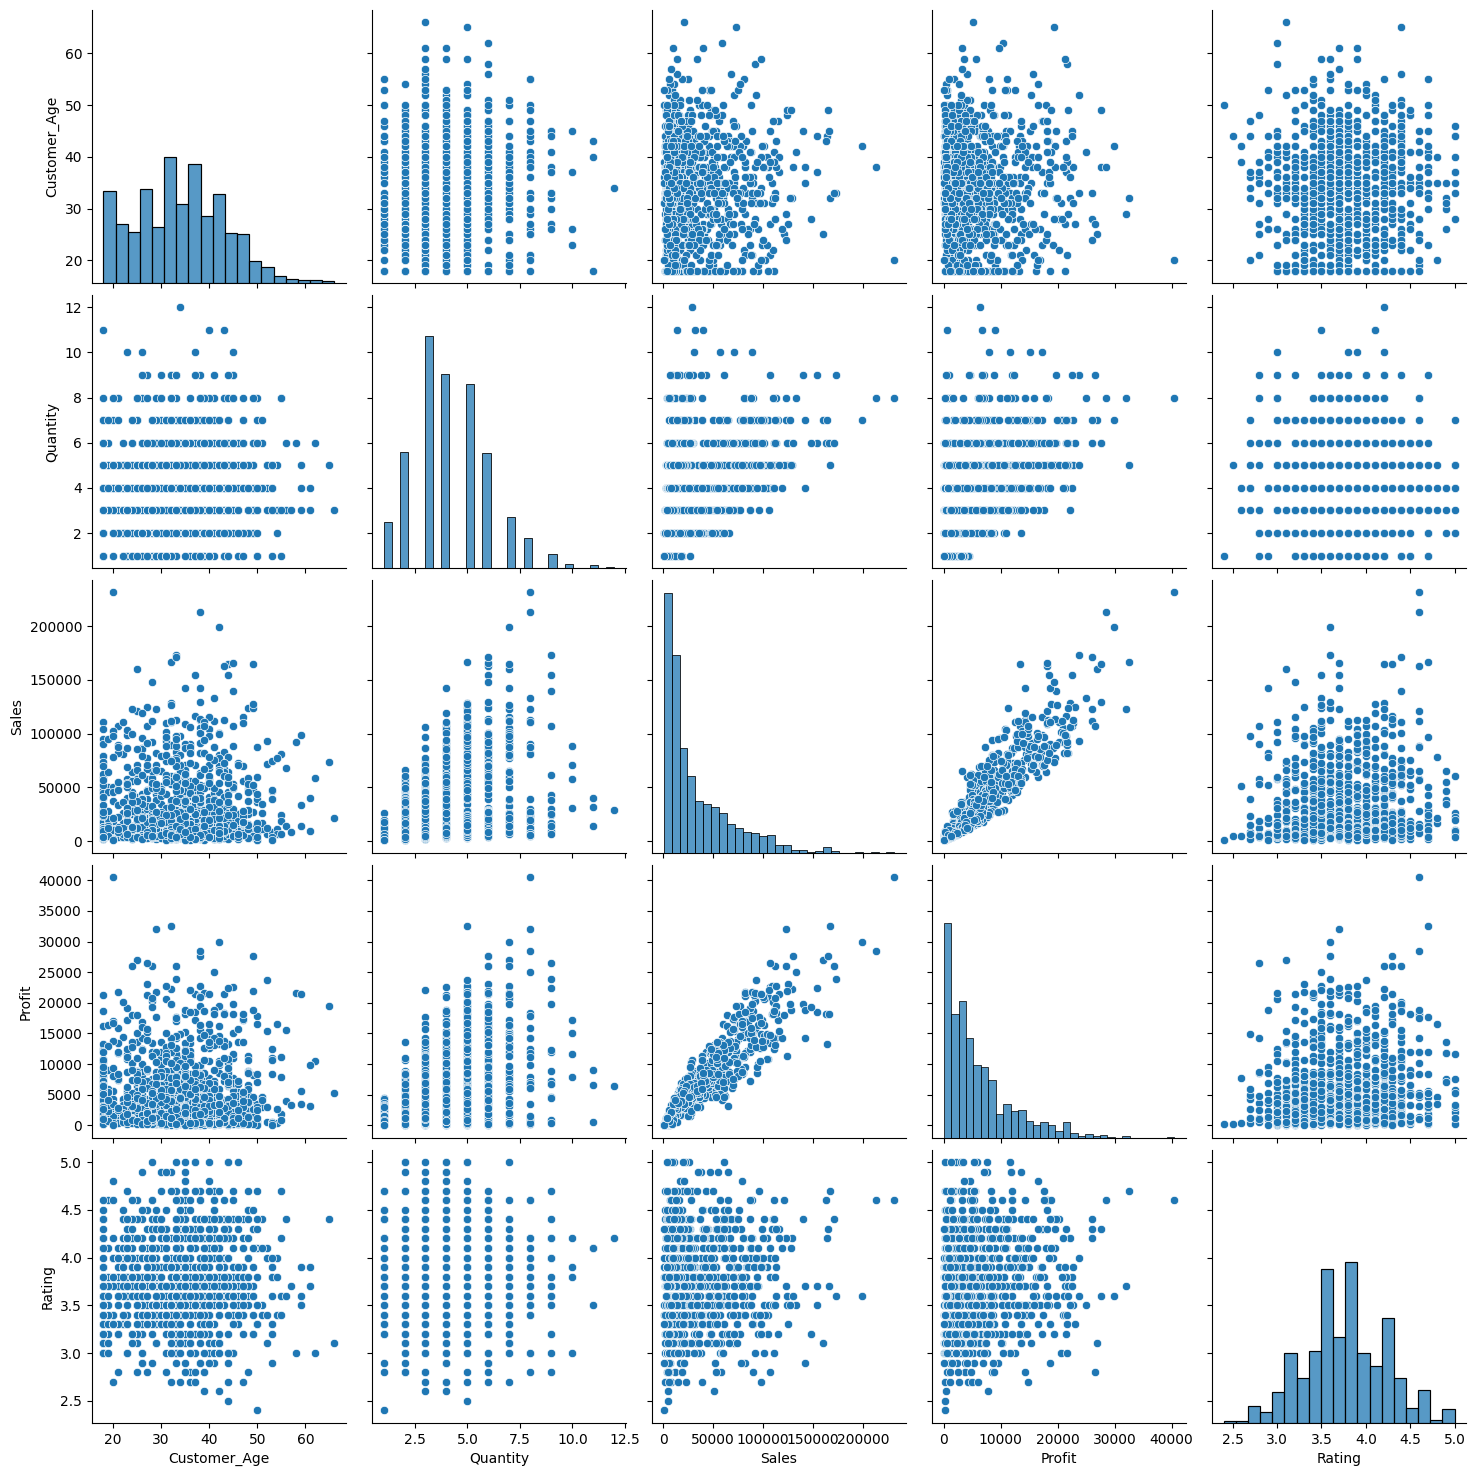

In [16]:
# Pairplot
pairplot_cols = [
    "Customer_Age",
    "Quantity",
    "Sales",
    "Profit",
    "Rating",
]

pair_df = df[pairplot_cols + ["Category"]].sample(1000, random_state=42)

sns.pairplot(pair_df, height=3)
plt.show()


## Which Columns Were Used?

| Visualization | Main columns |
|---|---|
| Bar Graph | `Category`, `Profit` |
| Histogram | `Sales` |
| Line Graph | `Order_Date`, `Sales` |
| Time Series | `Order_Date`, `Sales` |
| Scatter Plot | `Marketing_Spend`, `Sales`, `Category` |
| Count Plot | `Customer_Segment` |
| Bubble Chart | `Customer_Age`, `Sales`, `Profit`, `Category` |
| Pie Chart | `Category`, `Sales` |
| Box Plot | `Category`, `Sales` |
| Heatmap | Numerical columns |
| Pairplot | Selected numerical columns + `Category` |

